## Affinity threshold determination

This report evaluates **DrugCLIP** performance on two labeled datasets: DUD-E and LIT-PCBA. We provide recommended **affinity thresholds** based on estimated false positive rates (FPR) to guide molecular selection and prioritization.

### Directory of Useful Decoys, Enhanced (DUD-E) dataset

The DUD-E dataset contains 22,886 active compounds spanning 102 protein targets. For each active compound, 50 decoys were generated with similar physicochemical properties to act as negatives.

DrugCLIP reports an enrichment factor at 1% (EF1%) of 24.61 across all DUD-E targets, outperforming several standard docking tools.

**EF1%** quantifies how enriched true binders are in the top 1% of ranked molecules compared to a random selection.

$$
\text{EF}_{\alpha}=\frac{\text{NTB}_{\alpha}}{\text{NTB}_{t}\times\alpha}
$$

Where $\text{NTB}_{\alpha}$ is the number of true binders found in the top $\alpha$ fraction of the ranking, $\text{NTB}_{t}$ is the total number of true binders and $\alpha$ is the fraction of molecules considered (e.g., 0.01 for top 1%).

In [22]:
import os
import pandas as pd
import numpy as np
affinity_experiments = []
for file in os.listdir("/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing"):
    if file.endswith(".txt"):
        affinity_experiments.append(file)

The average EF1% achieved by DrugCLIP across the 102 targets in DUD-E is computed here below.

In [23]:
def ef1(data, alfa = 0.01):
    top_n = max(1, int(alfa * len(data)))
    top_molecules = data.iloc[:top_n]
    active_in_top = (top_molecules["label"]==1).sum()
    total_active = (data["label"]==1).sum()
    return active_in_top/(total_active*alfa)

ef1_dude = []
ordered = 0
for file in affinity_experiments:
    path_file = os.path.join("/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing", file)
    data = pd.read_csv(path_file, sep=",", header=None)
    data.columns = ["name", "cosine", "score", "label"]
    if (data["cosine"].argsort() == data["score"].argsort()).all():
        ordered += 1

    ef1_dude.append(ef1(data))

print(f"EF1% Mean across {len(affinity_experiments)} DUD-E targets: {np.array(ef1_dude).mean():.2f}")
print(f"EF1% standard deviation across {len(affinity_experiments)} DUD-E targets: {np.array(ef1_dude).std():.2f}")
            

EF1% Mean across 102 DUD-E targets: 26.31
EF1% standard deviation across 102 DUD-E targets: 20.50


The EF1% for each target/experiment is shown in the figure below. 

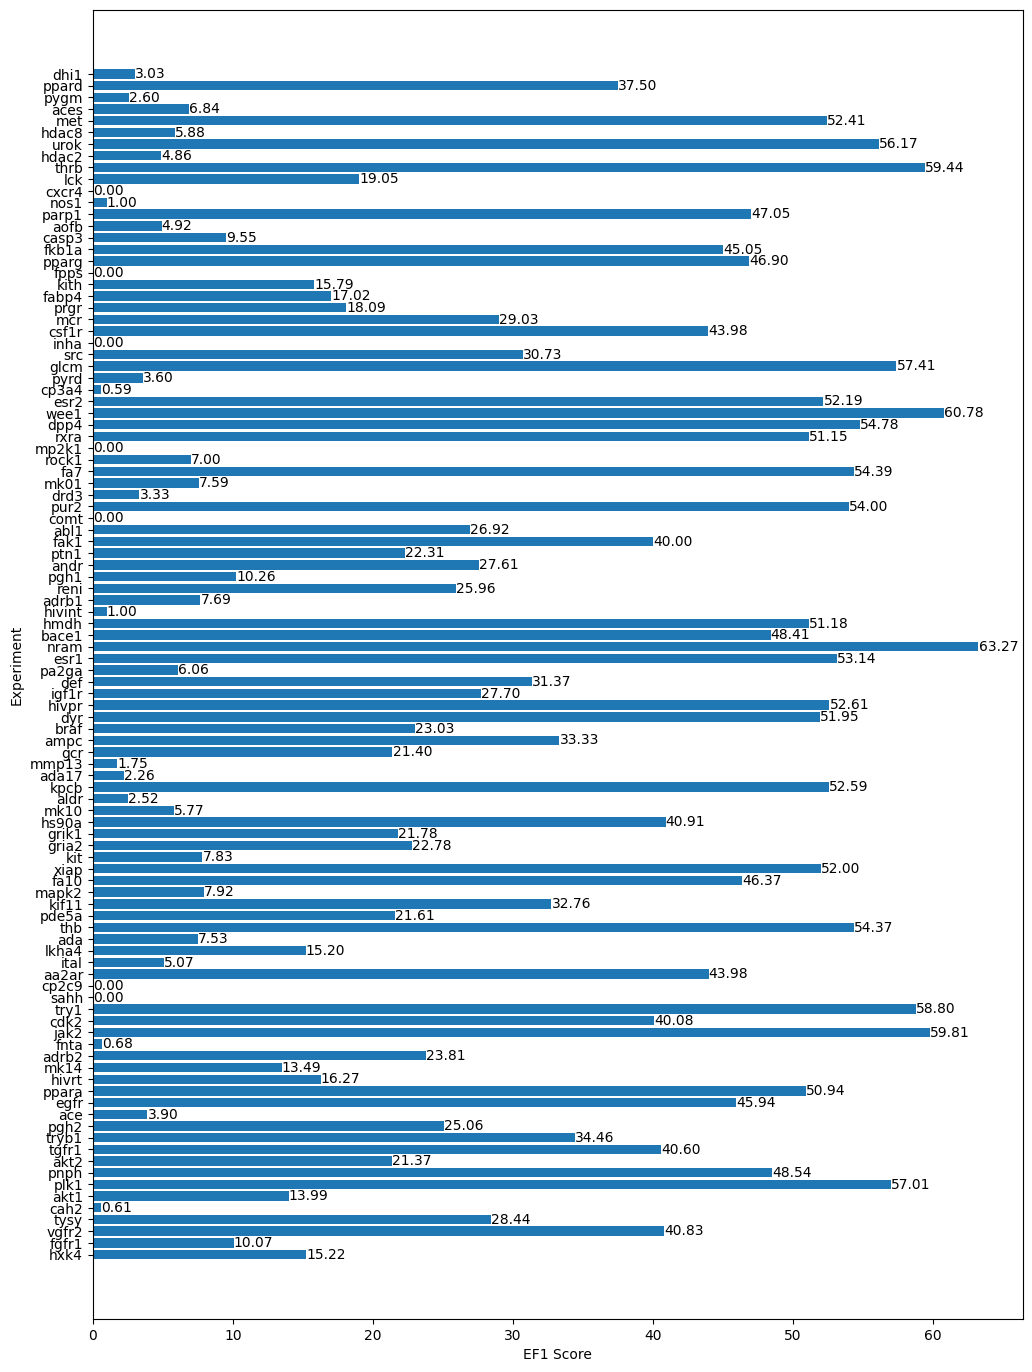

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,17))
bars = plt.barh([exp.replace(".txt", "") for exp in affinity_experiments], ef1_dude)
plt.ylabel('Experiment')
plt.xlabel('EF1 Score')

for bar in bars:
    width = bar.get_width()
    plt.text(width+0.01, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center')

plt.show()

The histograms of the cosine similarity for active and inactive compounds of 16 randomly selected targets are shown below. 

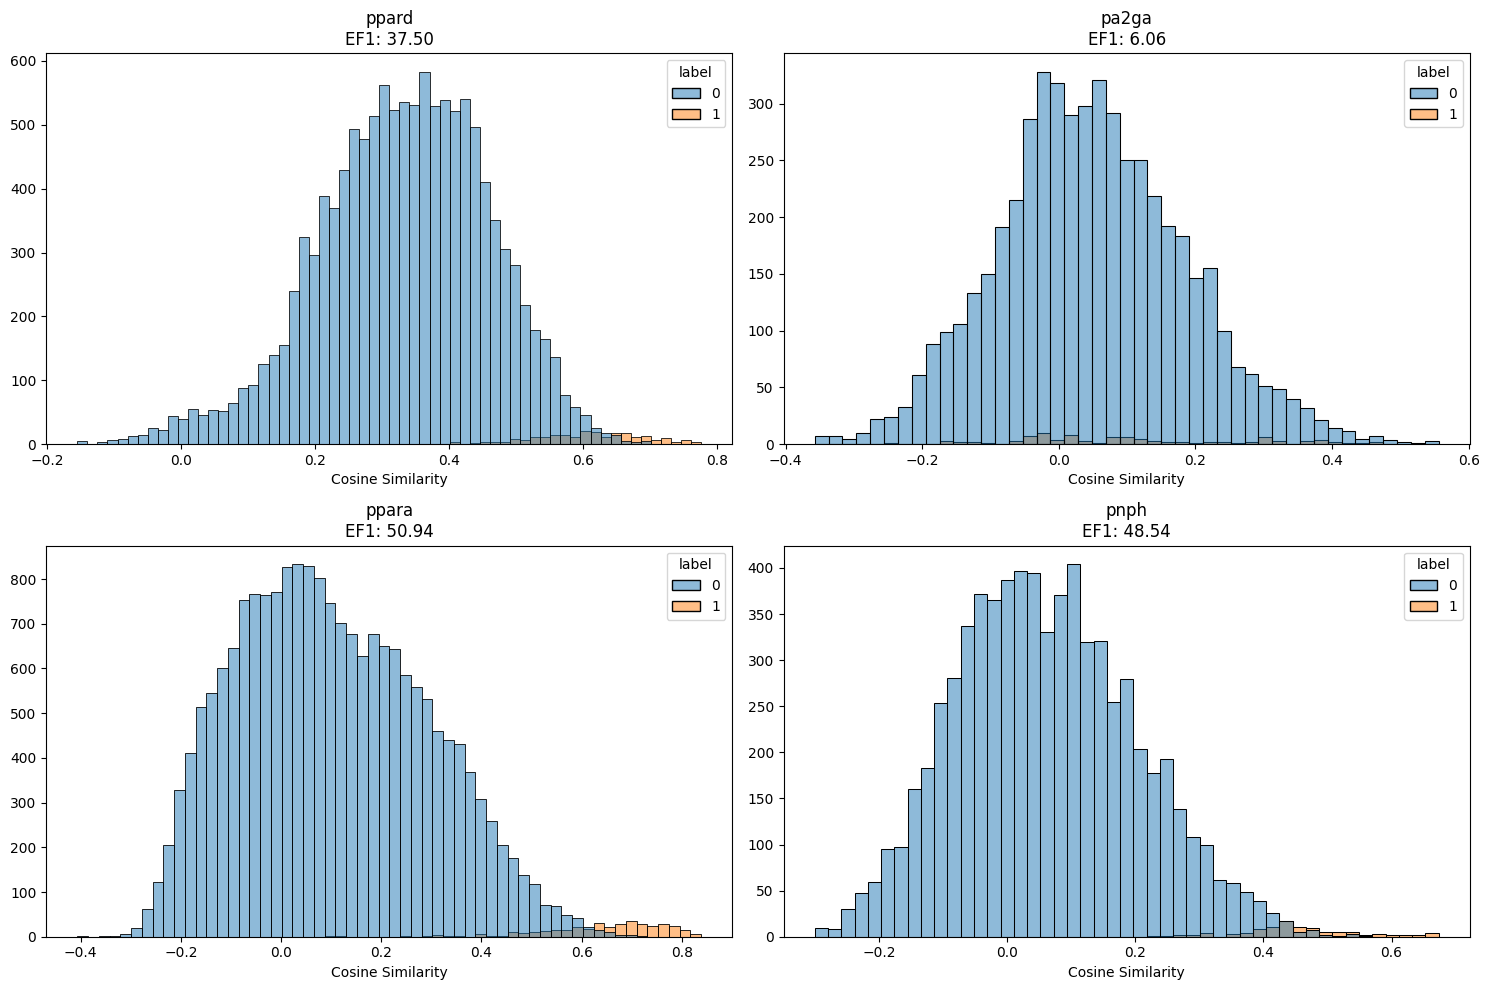

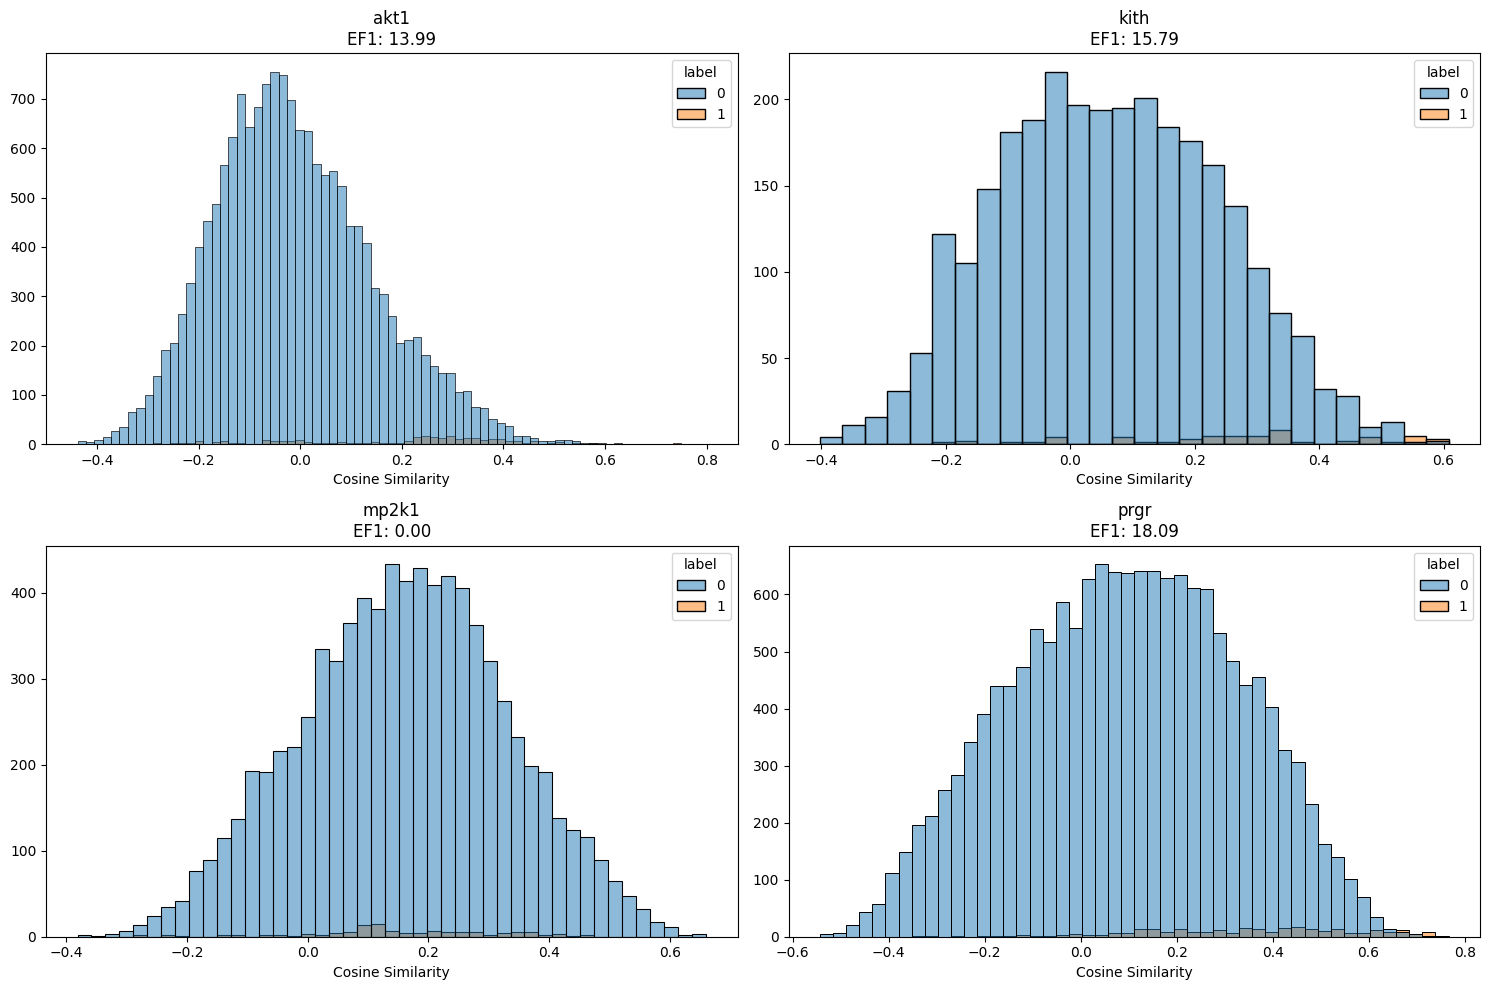

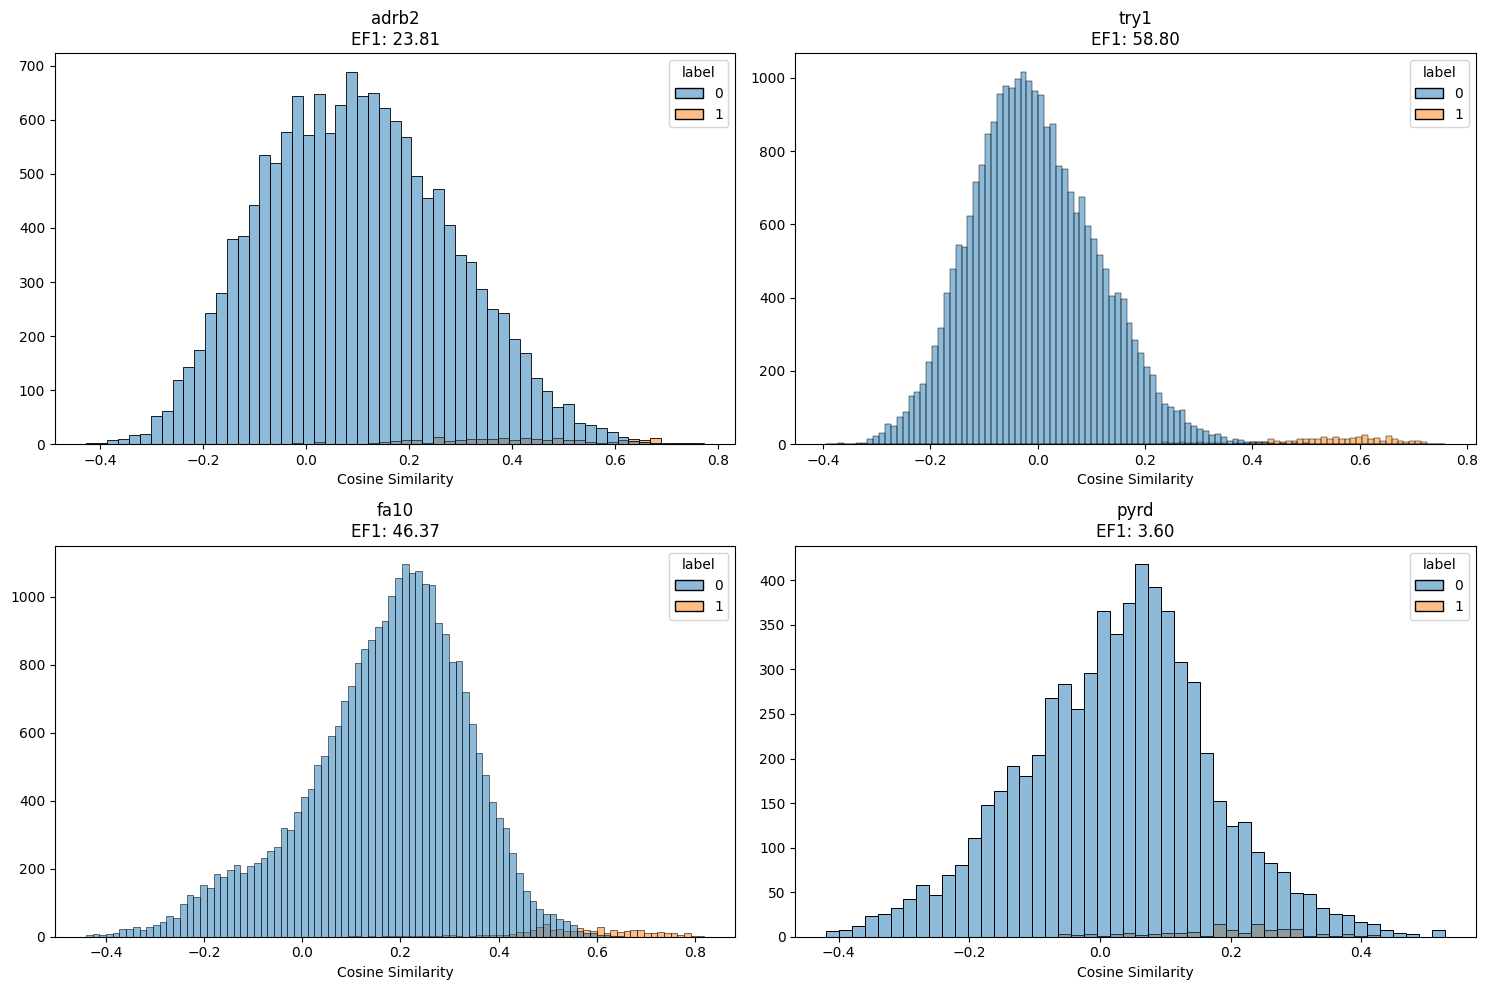

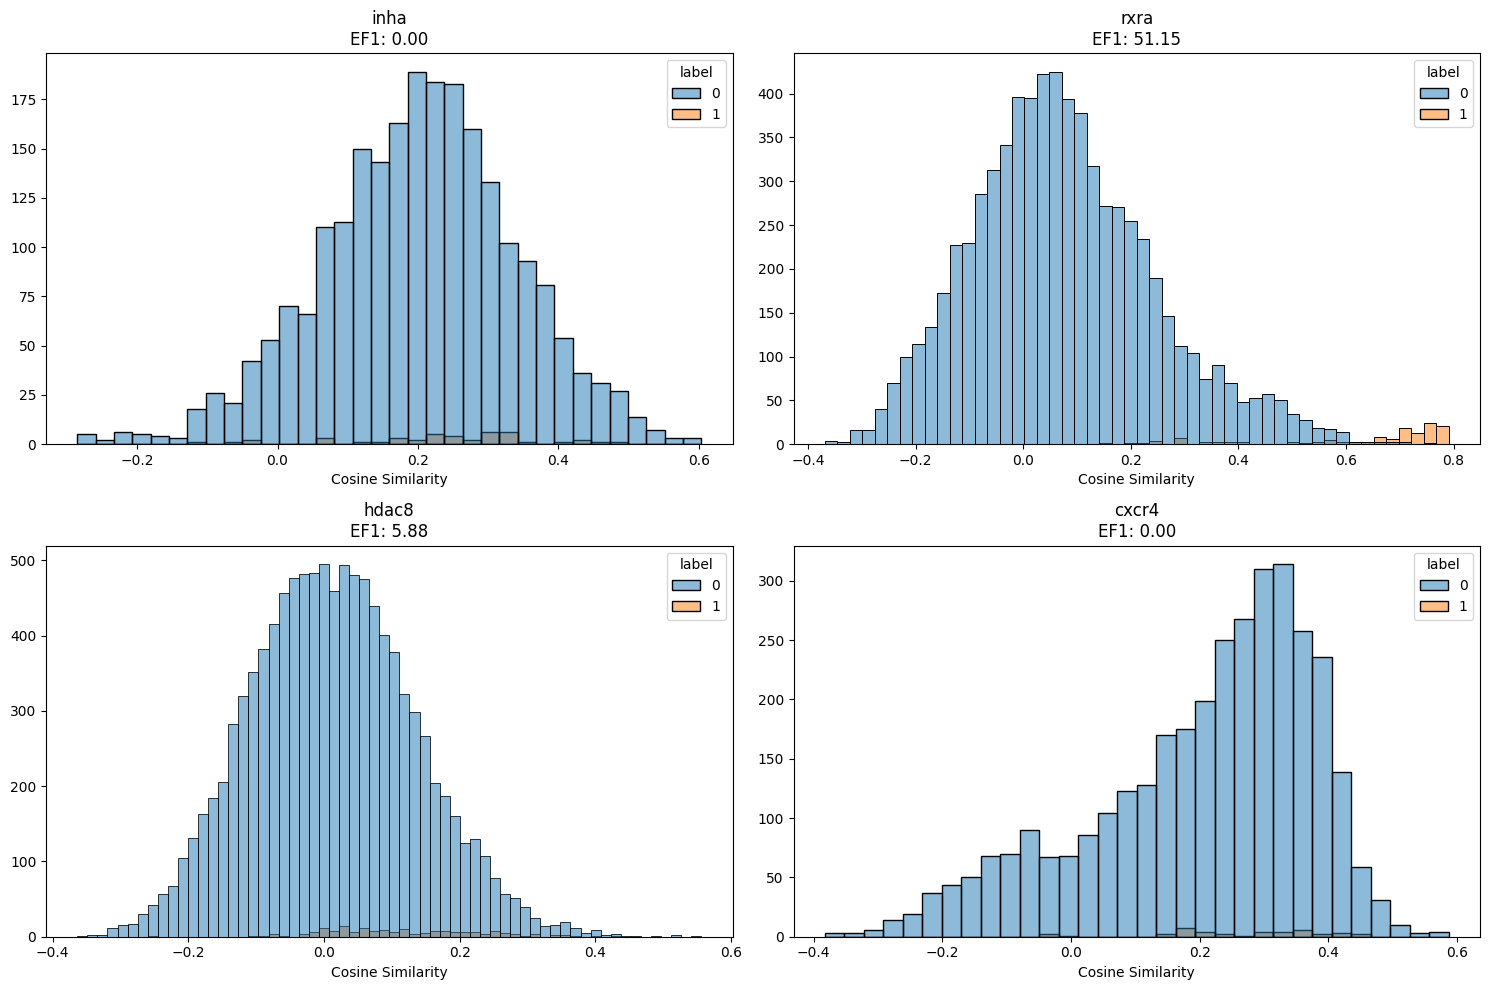

In [25]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

files_per_fig = 4
nrows, ncols = 2, 2

random.seed(42) 
rand_affinity_experiments = np.random.choice(affinity_experiments, size=16, replace=False)

for i in range(0, len(rand_affinity_experiments), files_per_fig):

    subset = rand_affinity_experiments[i:i+files_per_fig]

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10))
    axes = axes.flatten()

    for ax, file in zip(axes, subset):

        path_file = os.path.join(
            "/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing",
            file
        )

        data = pd.read_csv(path_file, sep=",", header=None)
        data.columns = ["name", "cosine", "score", "label"]

        sns.histplot(data=data, x="cosine", hue="label", ax=ax)

        ax.set_title(
            f"{file.replace('.txt','')}\nEF1: {ef1(data):.2f}"
        )
        ax.set_xlabel("Cosine Similarity")
        ax.set_ylabel("")

    # hide empty axes if last figure has fewer plots
    for ax in axes[len(subset):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

In [26]:
def fpr(threshold, data, col_name = "cosine"):
    fp = ((data[col_name] >= threshold) & (data["label"] == 0)).sum()
    inactive_molecules = (data["label"]==0).sum()
    return fp/inactive_molecules

threshold_by_fpr = {}
for x in np.round(np.linspace(0.01, 0.10, num=10), 2):
    fpr_selected = []
    threshold_selected = []
    for file in affinity_experiments:
        path_file = os.path.join("/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing", file)
        data = pd.read_csv(path_file, sep=",", header=None)
        data.columns = ["name", "cosine", "score", "label"]
        threshold_options = np.linspace(-1, 1, num=100)
        fpr_values = [fpr(t, data, "cosine") for t in threshold_options]
        closest_index = min(range(len(fpr_values)), key=lambda i: abs(fpr_values[i] - x))
        closest_value = fpr_values[closest_index]
        fpr_selected.append(closest_value)
        threshold_selected.append(threshold_options[closest_index])
    
    fpr_mean = np.round(np.array(fpr_selected).mean(), 2)
    if fpr_mean not in threshold_by_fpr:
        threshold_by_fpr[fpr_mean] = [np.array(threshold_selected).mean(), np.array(threshold_selected).std()]

To facilitate the interpretation of DrugCLIP cosine similarity, we estimate score thresholds corresponding to specific false positive rate (FPR) levels across DUD-E targets. 

For a given cosine similarity threshold $t$, the **FPR** is defined as:

$$
\text{FPR(t)} = \frac{\text{FP(t)}}{\text{FP(t)}+TN} = \frac{\text{FP(t)}}{\text{N}_{\text{inactive}}}
$$

Where $FP(t)$ is the number of inactive molecules with cosine similarity $\geq \text{t}$ and $\text{N}_{\text{inactive}}$ is the total number of inactive molecules in the dataset.

The following **steps** are conducted:
1. Define a set of target FPR values in the range 0.01–0.20.
2. For each DUD-E experiment:
    - Compute $FPR(t)$ for a grid of cosine similarity thresholds $t\in [-1,1]$
    - Identify the threshold $t$ whose FPR is closest to the desired target FPR.
3. Collect the selected thresholds and FPR values across all targets.
4. Compute the mean FPR and mean cosine similarity threshold across targets.

This produces a mapping between expected false positive rates and cosine similarity thresholds:

In [27]:

def dict_to_markdown_table(d):
    col1 = "Estimated FPR"
    col2 = "Cosine similarity threshold"
    col3 = "Threshold SD"

    # Convert values to strings
    rows = [(str(k), str(v[0]), str(v[1])) for k, v in d.items()]

    # Compute column widths
    w1 = max(len(col1), max(len(k) for k, _, _ in rows))
    w2 = max(len(col2), max(len(v) for _, v, _ in rows))
    w3 = max(len(col3), max(len(std) for _, _, std in rows))

    header = f"| {col1:<{w1}} | {col2:<{w2}} | {col3:<{w3}} |\n"
    separator = f"| {'-'*w1} | {'-'*w2} | {'-'*w3} |\n"

    body = "\n".join(
        f"| {k:<{w1}} | {v:<{w2}} | {std:<{w3}} |"
        for k, v, std in rows
    )

    return header + separator + body

d_rounded = {k: [round(v[0], 2), round(v[1], 2)] if isinstance(v, list) else v for k, v in threshold_by_fpr.items()}

print(dict_to_markdown_table(d_rounded))

| Estimated FPR | Cosine similarity threshold | Threshold SD |
| ------------- | --------------------------- | ------------ |
| 0.01          | 0.43                        | 0.1          |
| 0.02          | 0.39                        | 0.1          |
| 0.03          | 0.36                        | 0.1          |
| 0.04          | 0.34                        | 0.1          |
| 0.05          | 0.33                        | 0.11         |
| 0.06          | 0.31                        | 0.1          |
| 0.07          | 0.3                         | 0.11         |
| 0.08          | 0.29                        | 0.1          |
| 0.09          | 0.28                        | 0.11         |
| 0.1           | 0.27                        | 0.1          |


Below, the average false positive rate (FPR) and true positive rate (TPR) curves across all targets in the DUD-E dataset are shown for the full range of cosine similarity thresholds.

In [28]:

def tpr(threshold, data, col_name = "cosine"):
    tp = ((data[col_name] >= threshold) & (data["label"] == 1)).sum()
    active_molecules = (data["label"]==1).sum()
    return tp/active_molecules

fpr_dataset = []
tpr_dataset = []
for file in affinity_experiments:
    path_file = os.path.join("/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing", file)
    data = pd.read_csv(path_file, sep=",", header=None)
    data.columns = ["name", "cosine", "score", "label"]
    threshold_options = np.linspace(-1, 1, num=100)
    fpr_values = [fpr(t, data, "cosine") for t in threshold_options]
    tpr_values = [tpr(t, data, "cosine") for t in threshold_options]
    fpr_dataset.append(fpr_values)
    tpr_dataset.append(tpr_values)


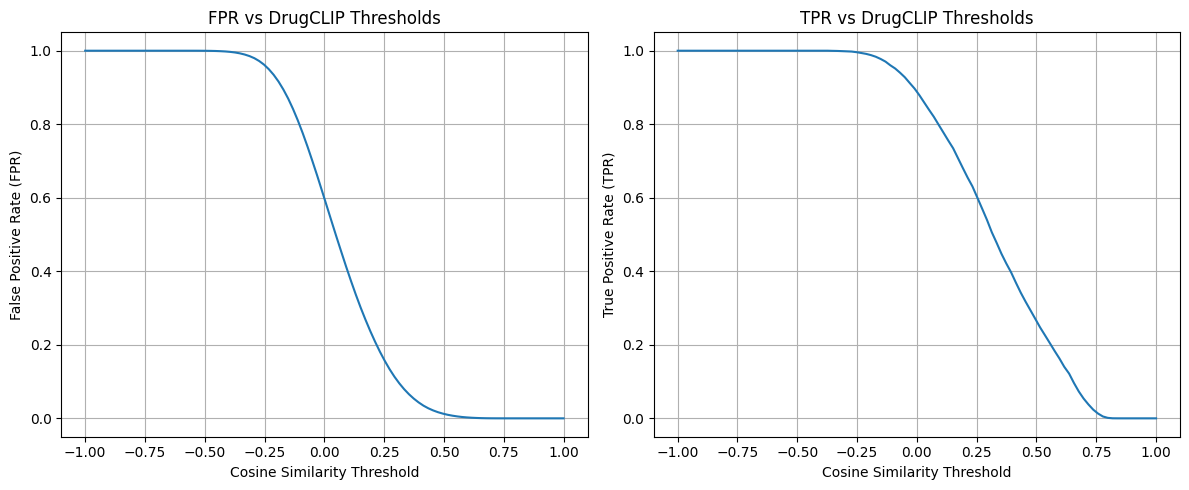

In [29]:
import matplotlib.pyplot as plt
import numpy as np

fpr_dataset = np.array(fpr_dataset)
tpr_dataset = np.array(tpr_dataset)

fpr_dataset_mean = fpr_dataset.mean(axis=0)
tpr_dataset_mean = tpr_dataset.mean(axis=0)

thresholds = np.linspace(-1, 1, num=100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# FPR plot
axes[0].plot(thresholds, fpr_dataset_mean)
axes[0].set_ylabel("False Positive Rate (FPR)")
axes[0].set_xlabel("Cosine Similarity Threshold")
axes[0].set_title("FPR vs DrugCLIP Thresholds")
axes[0].grid(True)

# TPR plot
axes[1].plot(thresholds, tpr_dataset_mean)
axes[1].set_ylabel("True Positive Rate (TPR)")
axes[1].set_xlabel("Cosine Similarity Threshold")
axes[1].set_title("TPR vs DrugCLIP Thresholds")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### LIT-PCBA

The LIT-PCBA dataset contains 7,844 active compounds and 407,381 inactive compounds spanning 15 protein targets. 

DrugCLIP reports an enrichment factor at 1% (EF1%) of 5.36 across all LIT-PCBA targets, outperforming several standard docking tools.

In [30]:
import os
import pandas as pd
import numpy as np
affinity_experiments = []
for file in os.listdir("/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing_litpcba"):
    if file.endswith(".txt"):
        affinity_experiments.append(file)

The average EF1% achieved by DrugCLIP across the 15 targets in LIT-PCBA is computed below. For each molecule, the pocket conformation with the maximum cosine similarity is selected, and ligands are ranked according to this maximum score.

In [31]:
ef1_litpcba = []
for file in affinity_experiments:
    path_file = os.path.join("/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing_litpcba", file)
    data = pd.read_csv(path_file, sep=",")
    cosine_cols = data.filter(regex="cosine")
    data["cosine_max"] = cosine_cols.max(axis=1)
    data["cosine_max_col"] = cosine_cols.idxmax(axis=1)
    data["best_pocket"] = data["cosine_max_col"].str.extract(r'(\d+)').astype(int)
    data_sorted = data.sort_values(by="cosine_max", ascending=False)
    ef1_litpcba.append(ef1(data_sorted))

print(f"EF1% Mean across {len(affinity_experiments)} LIT-PCBA targets: {np.array(ef1_litpcba).mean():.2f}")
print(f"EF1% standard deviation across {len(affinity_experiments)} LIT-PCBA targets: {np.array(ef1_litpcba).std():.2f}")

EF1% Mean across 15 LIT-PCBA targets: 5.62
EF1% standard deviation across 15 LIT-PCBA targets: 6.90


The EF1% for each target/experiment is shown in the figure below. 

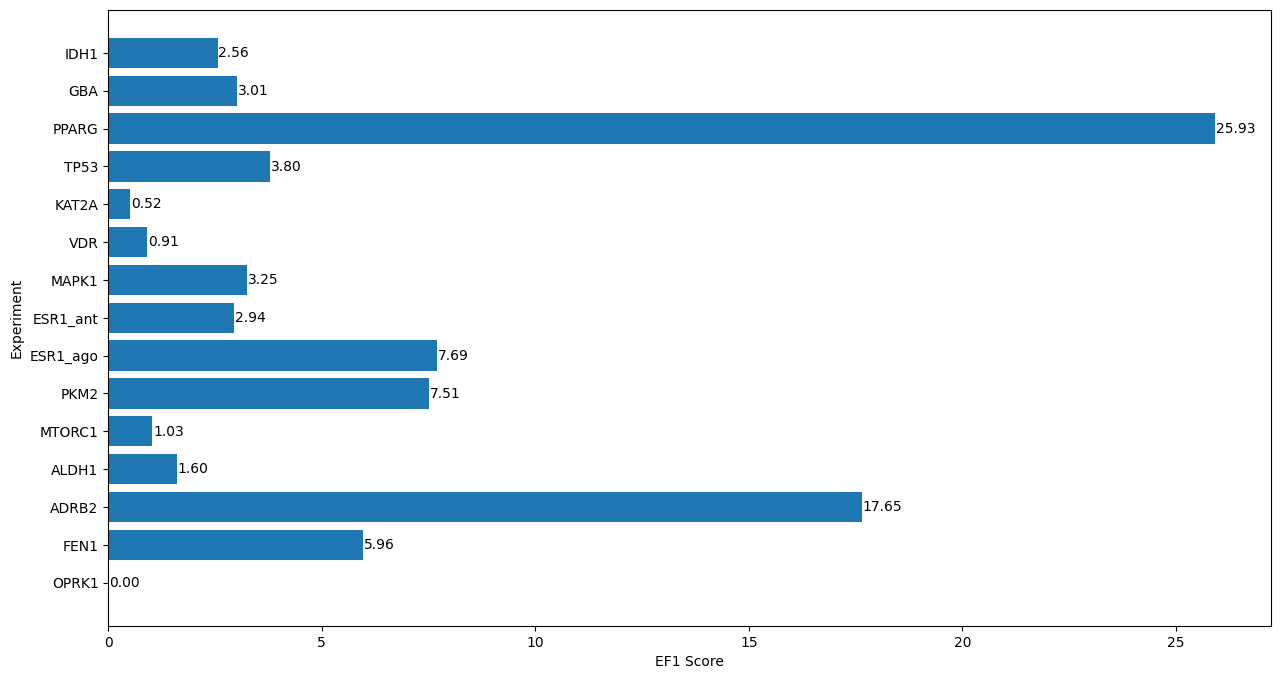

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,8))
bars = plt.barh([exp.replace(".txt", "") for exp in affinity_experiments], ef1_litpcba)
plt.ylabel('Experiment')
plt.xlabel('EF1 Score')

for bar in bars:
    width = bar.get_width()
    plt.text(width+0.015, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center')

plt.show()

Histograms of the cosine similarity corresponding to the pocket conformation with the maximum score are shown below for active and inactive compounds across the 15 targets.

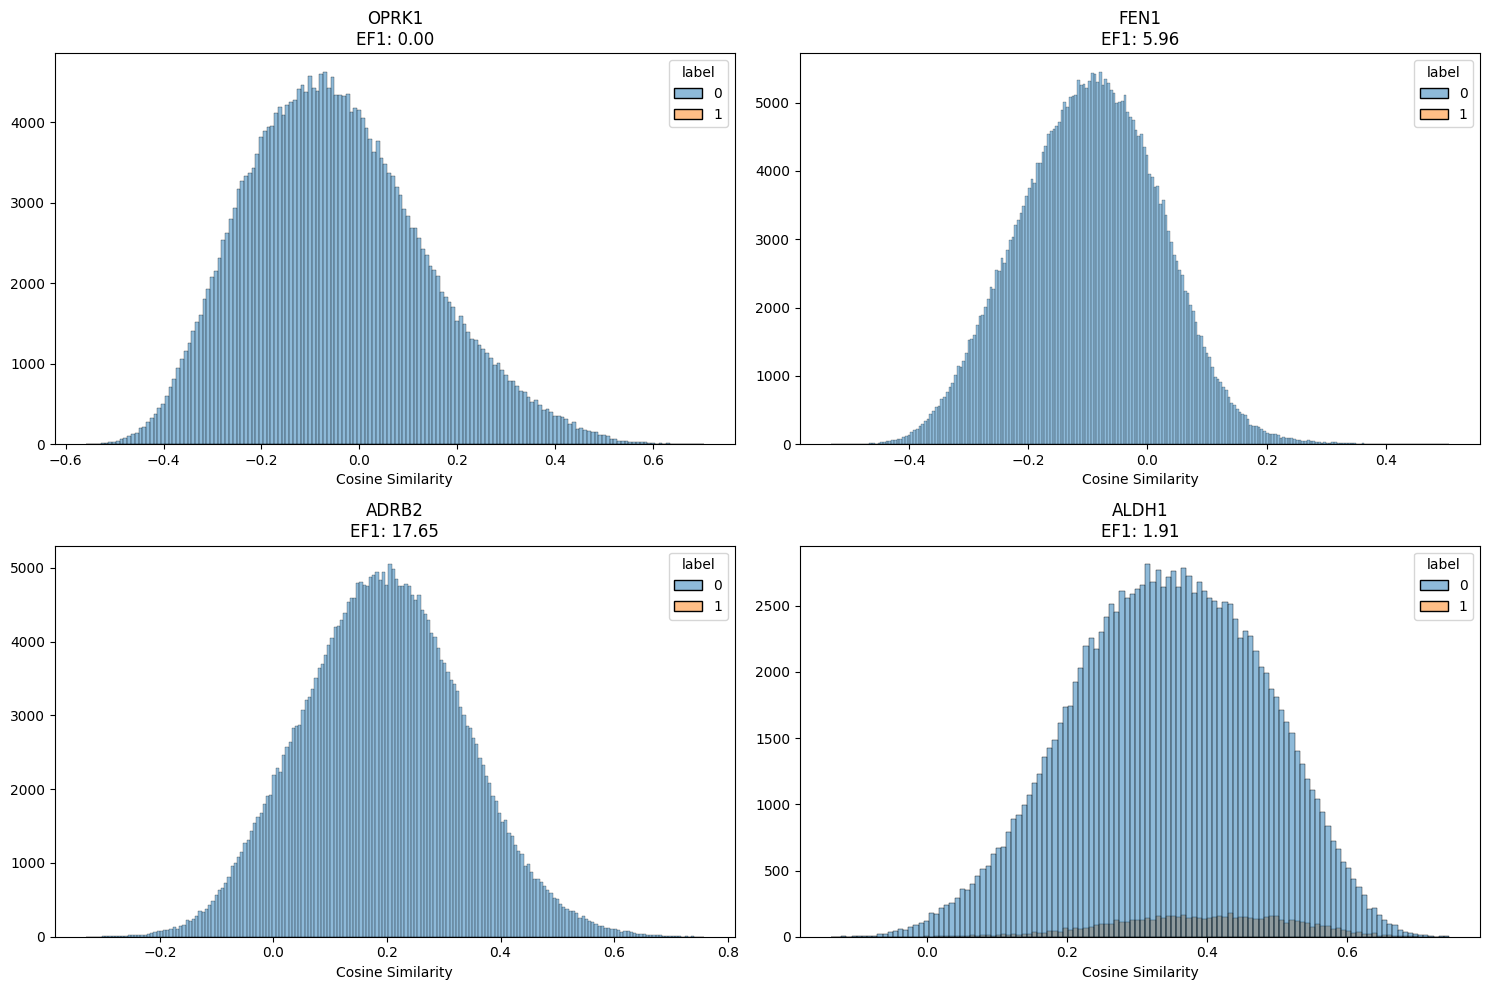

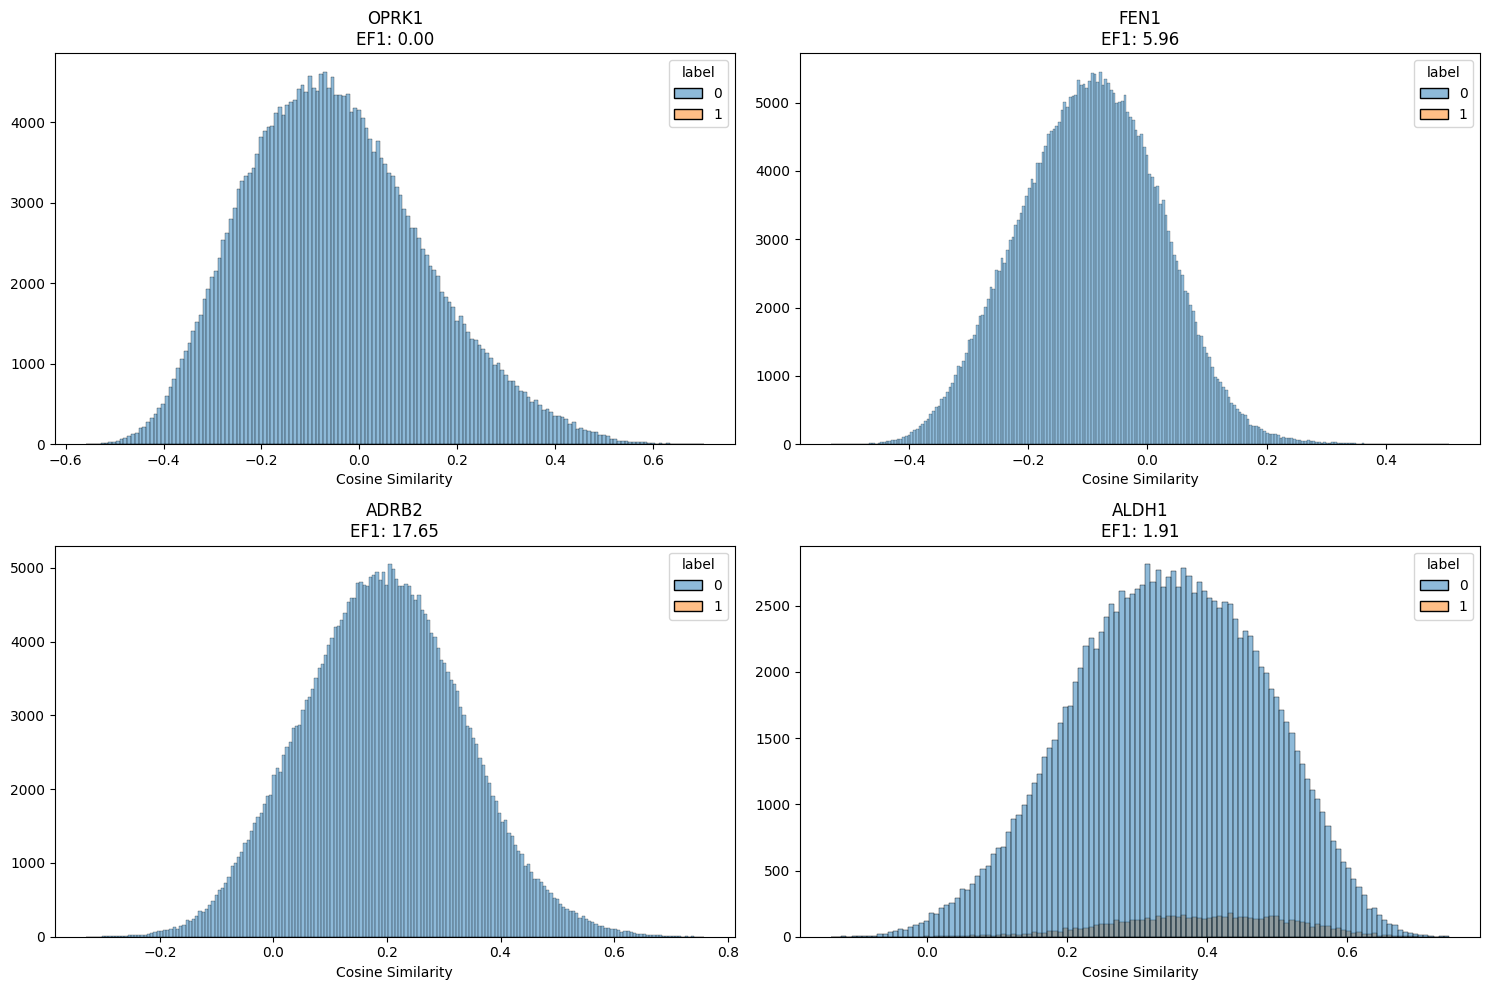

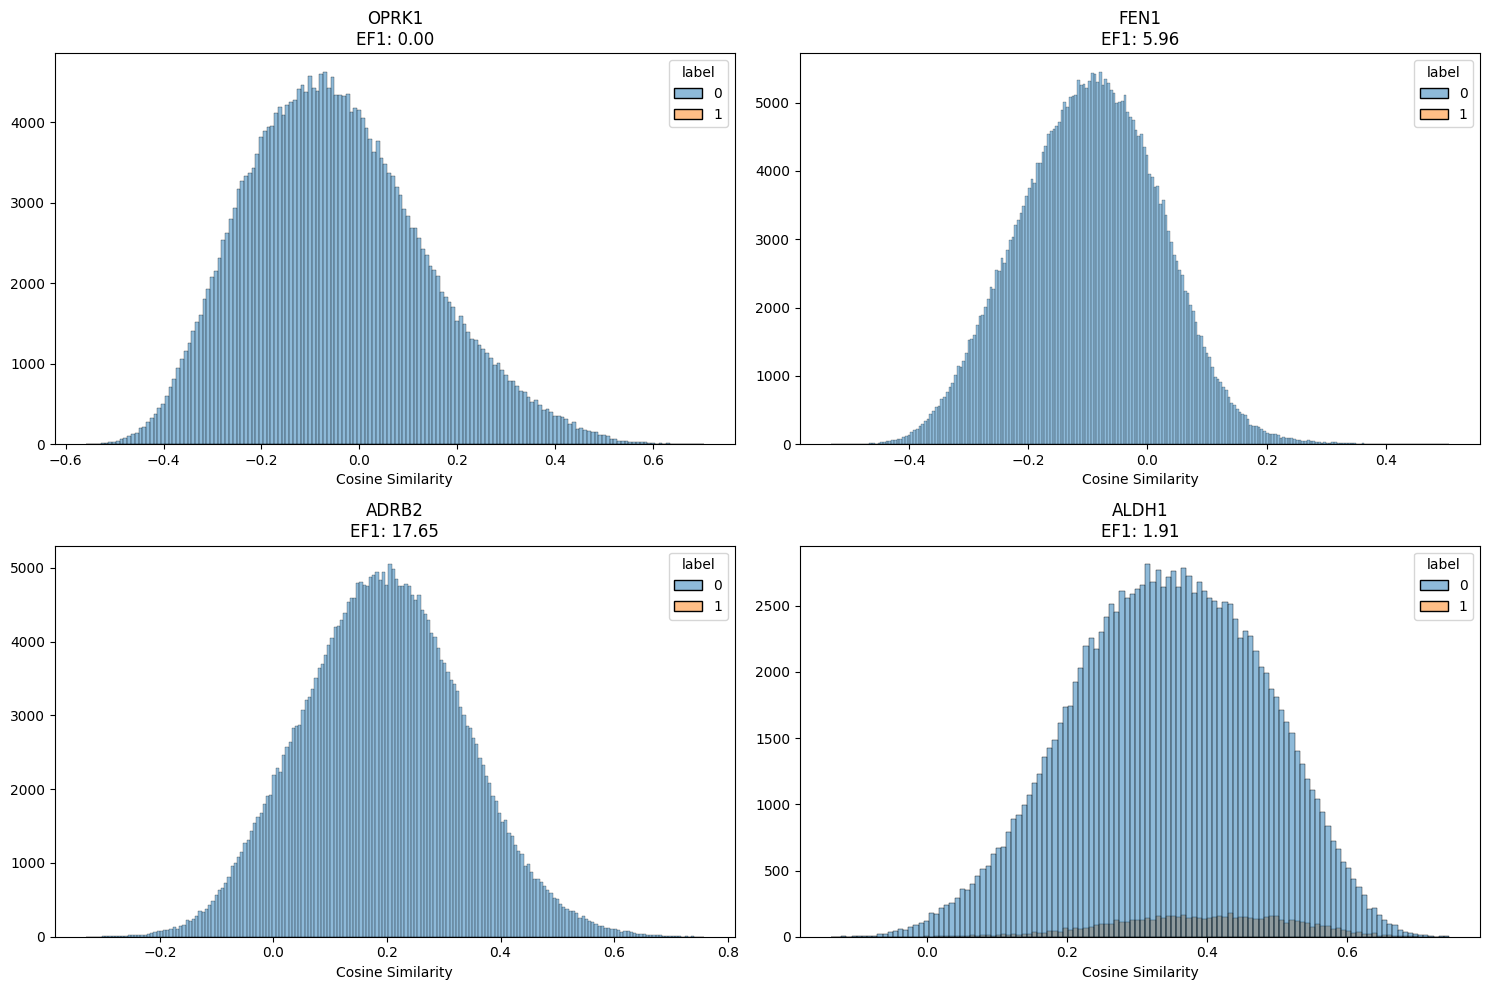

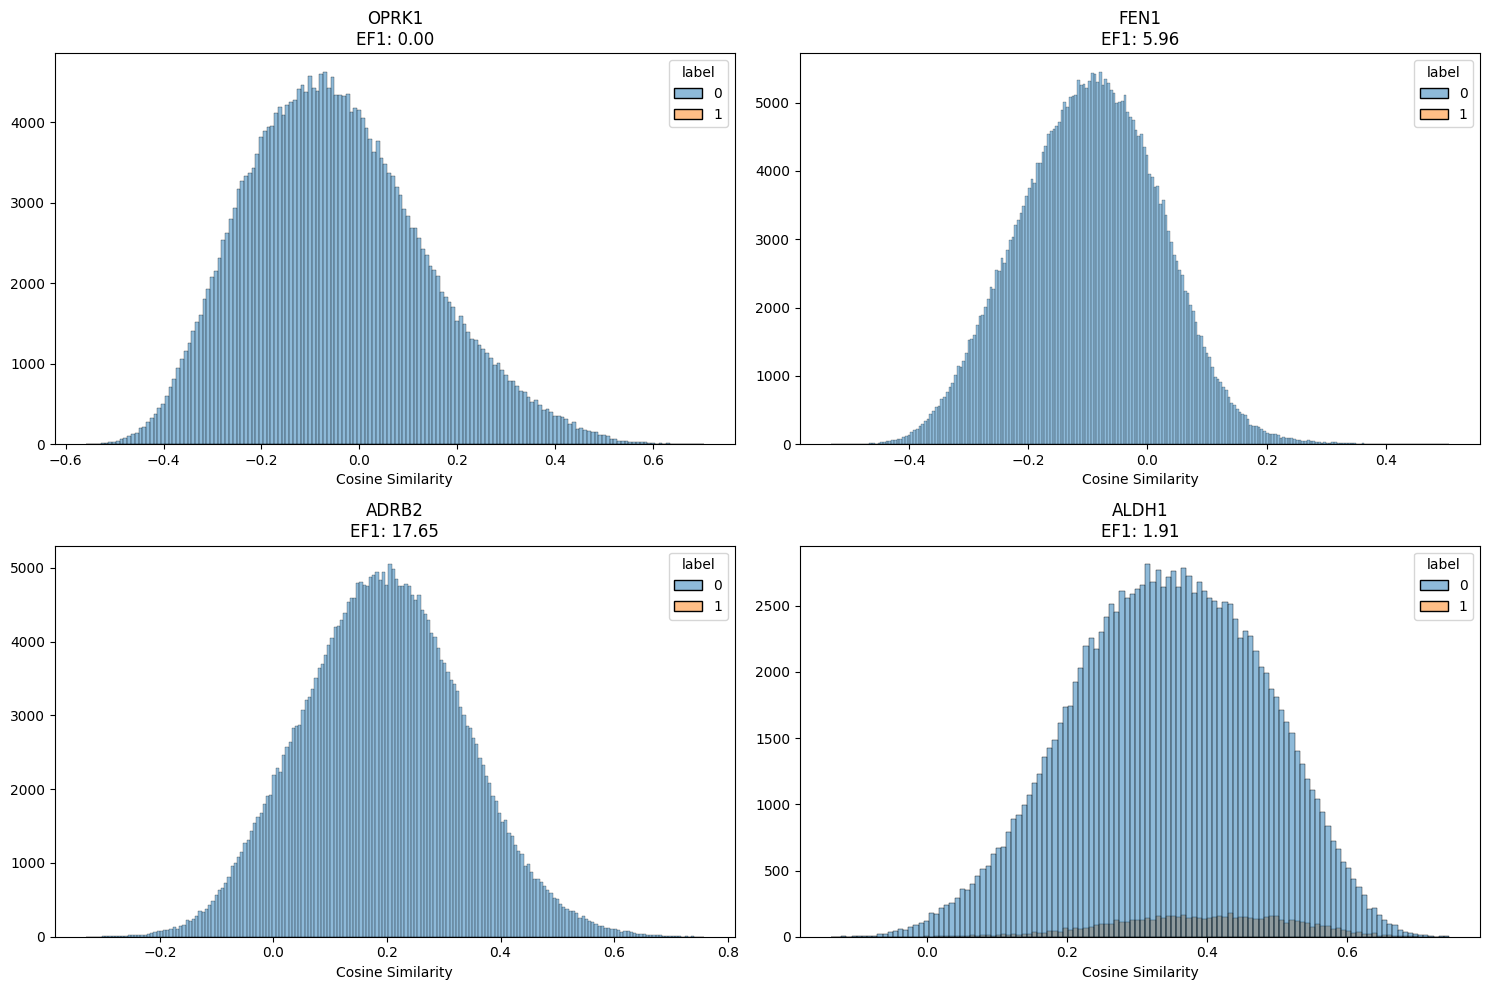

In [33]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

files_per_fig = 4
nrows, ncols = 2, 2

for i in range(0, len(affinity_experiments), files_per_fig):

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10))
    axes = axes.flatten()

    for ax, file in zip(axes, affinity_experiments):

        path_file = os.path.join(
            "/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing_litpcba",
            file
        )

        data = pd.read_csv(path_file, sep=",")
        cosine_cols = data.filter(regex="cosine")
        data["cosine_max"] = cosine_cols.max(axis=1)

        sns.histplot(data=data, x="cosine_max", hue="label", ax=ax)

        ax.set_title(
            f"{file.replace('.txt','')}\nEF1: {ef1(data):.2f}"
        )
        ax.set_xlabel("Cosine Similarity")
        ax.set_ylabel("")

    # hide empty axes if last figure has fewer plots
    for ax in axes[len(subset):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

In [34]:

threshold_by_fpr = {}
for x in np.round(np.linspace(0.01, 0.10, num=10), 2):
    fpr_selected = []
    threshold_selected = []
    for file in affinity_experiments:
        path_file = os.path.join("/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing_litpcba", file)
        data = pd.read_csv(path_file, sep=",")
        cosine_cols = data.filter(regex="cosine")
        data["cosine_max"] = cosine_cols.max(axis=1)
        
        threshold_options = np.linspace(-1, 1, num=100)
        fpr_values = [fpr(t, data, "cosine_max") for t in threshold_options]
        closest_index = min(range(len(fpr_values)), key=lambda i: abs(fpr_values[i] - x))
        closest_value = fpr_values[closest_index]
        fpr_selected.append(closest_value)
        threshold_selected.append(threshold_options[closest_index])
    
    fpr_mean = np.round(np.array(fpr_selected).mean(), 2)
    if fpr_mean not in threshold_by_fpr:
        threshold_by_fpr[fpr_mean] = [np.array(threshold_selected).mean(), np.array(threshold_selected).std()]

Thresholds corresponding to specific FPR levels across LIT-PCBA targets are computed in the same way as before, but considering the pocket conformations with the maximum cosine similarity score.

In [35]:
def dict_to_markdown_table(d):
    col1 = "Estimated FPR"
    col2 = "Cosine similarity threshold"
    col3 = "Threshold SD"

    # Convert values to strings
    rows = [(str(k), str(v[0]), str(v[1])) for k, v in d.items()]

    # Compute column widths
    w1 = max(len(col1), max(len(k) for k, _, _ in rows))
    w2 = max(len(col2), max(len(v) for _, v, _ in rows))
    w3 = max(len(col3), max(len(std) for _, _, std in rows))

    header = f"| {col1:<{w1}} | {col2:<{w2}} | {col3:<{w3}} |\n"
    separator = f"| {'-'*w1} | {'-'*w2} | {'-'*w3} |\n"

    body = "\n".join(
        f"| {k:<{w1}} | {v:<{w2}} | {std:<{w3}} |"
        for k, v, std in rows
    )

    return header + separator + body

d_rounded = {k: [round(v[0], 2), round(v[1], 2)] if isinstance(v, list) else v for k, v in threshold_by_fpr.items()}

print(dict_to_markdown_table(d_rounded))

| Estimated FPR | Cosine similarity threshold | Threshold SD |
| ------------- | --------------------------- | ------------ |
| 0.01          | 0.49                        | 0.12         |
| 0.02          | 0.45                        | 0.12         |
| 0.03          | 0.42                        | 0.12         |
| 0.04          | 0.4                         | 0.12         |
| 0.05          | 0.39                        | 0.13         |
| 0.06          | 0.37                        | 0.12         |
| 0.07          | 0.35                        | 0.12         |
| 0.08          | 0.35                        | 0.12         |
| 0.09          | 0.34                        | 0.13         |
| 0.1           | 0.32                        | 0.12         |


Below, the average false positive rate (FPR) and true positive rate (TPR) curves across the 15 LIT-PCBA targets are shown for the full range of cosine similarity thresholds, considering the best pocket conformation for each molecule.

In [ ]:
fpr_dataset = []
tpr_dataset = []
for file in affinity_experiments:
    path_file = os.path.join("/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing_litpcba", file)
    data = pd.read_csv(path_file, sep=",")
    cosine_cols = data.filter(regex="cosine")
    data["cosine_max"] = cosine_cols.max(axis=1)

    threshold_options = np.linspace(-1, 1, num=100)
    fpr_values = [fpr(t, data, "cosine_max") for t in threshold_options]
    tpr_values = [tpr(t, data, "cosine_max") for t in threshold_options]
    fpr_dataset.append(fpr_values)
    tpr_dataset.append(tpr_values)

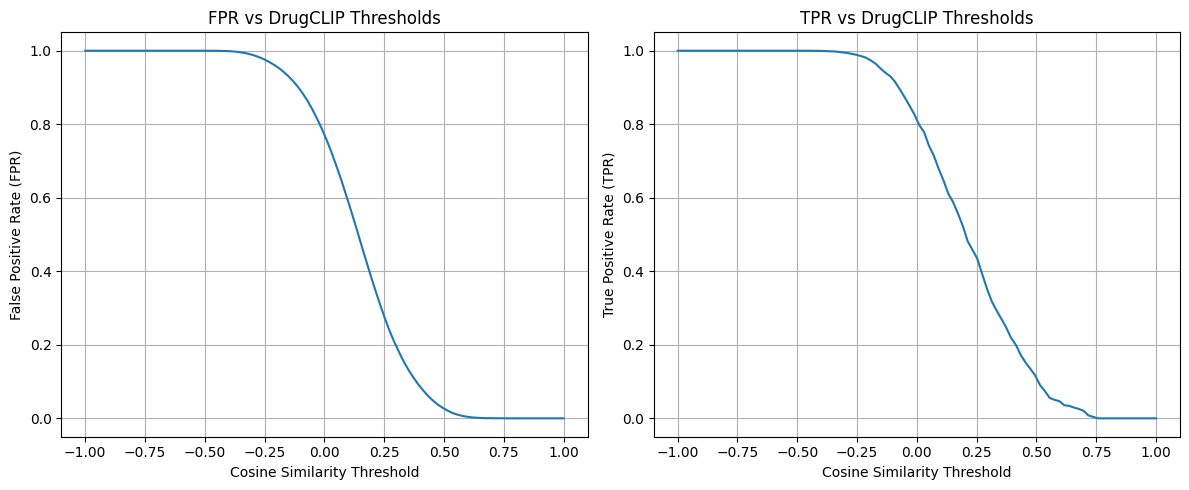

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fpr_dataset = np.array(fpr_dataset)
tpr_dataset = np.array(tpr_dataset)

fpr_dataset_mean = fpr_dataset.mean(axis=0)
tpr_dataset_mean = tpr_dataset.mean(axis=0)

thresholds = np.linspace(-1, 1, num=100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# FPR plot
axes[0].plot(thresholds, fpr_dataset_mean)
axes[0].set_ylabel("False Positive Rate (FPR)")
axes[0].set_xlabel("Cosine Similarity Threshold")
axes[0].set_title("FPR vs DrugCLIP Thresholds")
axes[0].grid(True)

# TPR plot
axes[1].plot(thresholds, tpr_dataset_mean)
axes[1].set_ylabel("True Positive Rate (TPR)")
axes[1].set_xlabel("Cosine Similarity Threshold")
axes[1].set_title("TPR vs DrugCLIP Thresholds")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [39]:
dude_exp = []
for file in os.listdir("/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing"):
    if file.endswith(".txt"):
        dude_exp.append(file)

litpcba_exp = []
for file in os.listdir("/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing_litpcba"):
    if file.endswith(".txt"):
        litpcba_exp.append(file)

Thresholds for all targets in the DUD-E and LIT-PCBA datasets are computed below.

In [ ]:
threshold_by_fpr = {}
for x in np.round(np.linspace(0.01, 0.10, num=10), 2):
    fpr_selected = []
    threshold_selected = []
    for file in dude_exp:
        path_file = os.path.join("/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing", file)
        data = pd.read_csv(path_file, sep=",", header=None)
        data.columns = ["name", "cosine", "score", "label"]
        threshold_options = np.linspace(-1, 1, num=100)
        fpr_values = [fpr(t, data, "cosine") for t in threshold_options]
        closest_index = min(range(len(fpr_values)), key=lambda i: abs(fpr_values[i] - x))
        closest_value = fpr_values[closest_index]
        fpr_selected.append(closest_value)
        threshold_selected.append(threshold_options[closest_index])
        
    for file in litpcba_exp:
        path_file = os.path.join("/home/mabarr/TCruzi_pipeline/threshold_experiments/normalizing_litpcba", file)
        data = pd.read_csv(path_file, sep=",")
        cosine_cols = data.filter(regex="cosine")
        data["cosine_max"] = cosine_cols.max(axis=1)
        
        threshold_options = np.linspace(-1, 1, num=100)
        fpr_values = [fpr(t, data, "cosine_max") for t in threshold_options]
        closest_index = min(range(len(fpr_values)), key=lambda i: abs(fpr_values[i] - x))
        closest_value = fpr_values[closest_index]
        fpr_selected.append(closest_value)
        threshold_selected.append(threshold_options[closest_index])
    
    fpr_mean = np.round(np.array(fpr_selected).mean(), 2)
    if fpr_mean not in threshold_by_fpr:
        threshold_by_fpr[fpr_mean] = [np.array(threshold_selected).mean(), np.array(threshold_selected).std()]


117
117
117
117
117
117
117
117
117
117


In [41]:
def dict_to_markdown_table(d):
    col1 = "Estimated FPR"
    col2 = "Cosine similarity threshold"
    col3 = "Threshold SD"

    # Convert values to strings
    rows = [(str(k), str(v[0]), str(v[1])) for k, v in d.items()]

    # Compute column widths
    w1 = max(len(col1), max(len(k) for k, _, _ in rows))
    w2 = max(len(col2), max(len(v) for _, v, _ in rows))
    w3 = max(len(col3), max(len(std) for _, _, std in rows))

    header = f"| {col1:<{w1}} | {col2:<{w2}} | {col3:<{w3}} |\n"
    separator = f"| {'-'*w1} | {'-'*w2} | {'-'*w3} |\n"

    body = "\n".join(
        f"| {k:<{w1}} | {v:<{w2}} | {std:<{w3}} |"
        for k, v, std in rows
    )

    return header + separator + body

d_rounded = {k: [round(v[0], 2), round(v[1], 2)] if isinstance(v, list) else v for k, v in threshold_by_fpr.items()}

print(dict_to_markdown_table(d_rounded))

| Estimated FPR | Cosine similarity threshold | Threshold SD |
| ------------- | --------------------------- | ------------ |
| 0.01          | 0.43                        | 0.11         |
| 0.02          | 0.39                        | 0.11         |
| 0.03          | 0.37                        | 0.11         |
| 0.04          | 0.35                        | 0.11         |
| 0.05          | 0.34                        | 0.11         |
| 0.06          | 0.32                        | 0.11         |
| 0.07          | 0.31                        | 0.11         |
| 0.08          | 0.3                         | 0.11         |
| 0.09          | 0.29                        | 0.11         |
| 0.1           | 0.28                        | 0.11         |


The resulting table provides a practical guideline for choosing DrugCLIP cosine similarity scores cutoffs or estimating the number of false positives expected when selecting the top $K$ molecules in the ranking.